Saving m4.jpg to m4.jpg
Optimal Threshold Value: 100.0


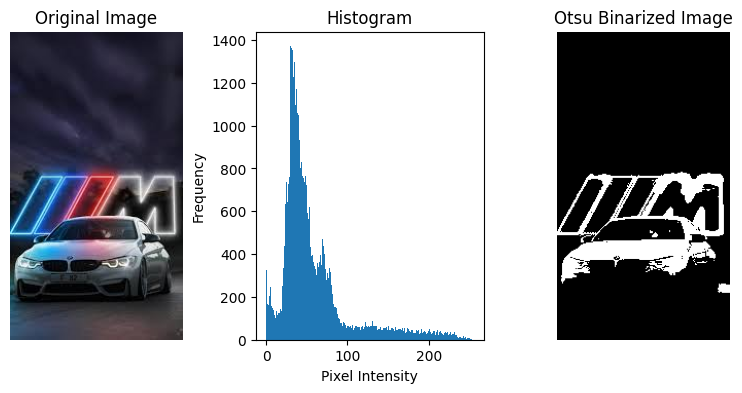

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
# Upload image
uploaded = files.upload()
#Get (tg://search_hashtag?hashtag=Get) uploaded file name
image_path = list(uploaded.keys())[0]
# Read image in grayscale
img = cv2.imread(image_path, 0)
img_1= cv2.imread(image_path)
img_rgb = cv2.cvtColor(img_1, cv2.COLOR_BGR2RGB)
if img is None:
    raise ValueError("Failed to load image!")
# Apply Otsu's Binarization
#Threshold (tg://search_hashtag?hashtag=Threshold) value is automatically calculated
#tnresnola (tg://search_hashtag?hashtag=tnresnola)(src, tnresn, maxval, type)
threshold_value, binary_img = cv2.threshold(
img,
100,
255,
#cv2 (tg://search_hashtag?hashtag=cv2).THRESH_BINARY + cv2.THRESH_OTSU #---- for using OTS
cv2.THRESH_BINARY
#v2.T (tg://search_hashtag?hashtag=v2)HRESH_BINARY_INV
)
print("Optimal Threshold Value:", threshold_value)
# Display results
plt.figure(figsize=(10,4))
plt.subplot(1,3,1)
plt.title("Original Image")
plt.imshow(img_rgb)
plt.axis("off")
plt.subplot(1,3,2)
plt.title("Histogram")
plt.hist(img.ravel(), 256)
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.subplot(1,3,3)
plt.title("Otsu Binarized Image")
plt.imshow(binary_img, cmap='gray')
plt.axis("off")
plt.show()

Total number of images (X): 1797
Total number of labels (y): 1797
SVM training completed.
Model Accuracy: 0.8166666666666667


Saving papa.jpg to papa.jpg


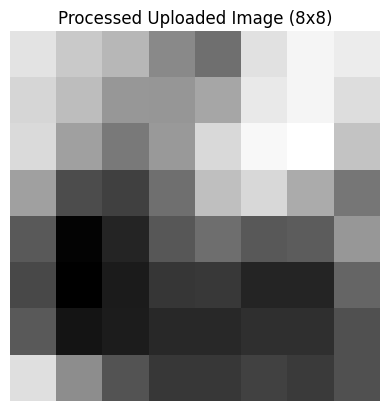

Predicted Digit: 5


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

from skimage.feature import hog
from skimage.transform import resize
digits = datasets.load_digits()
X = digits.images
y = digits.target

print("Total number of images (X):", X.shape[0])
print("Total number of labels (y):", y.shape[0])

features = []

for img in X:
    hog_feature = hog(
        img,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        orientations=9
    )
    features.append(hog_feature)

features = np.array(features)

X_train, X_test, y_train, y_test = train_test_split(
    features, y, test_size=0.2, random_state=42
)

model = SVC(kernel='linear')
model.fit(X_train, y_train)

print("SVM training completed.")

y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

from google.colab import files

uploaded = files.upload()

for file_name in uploaded.keys():
    img = cv2.imread(file_name)

    if len(img.shape) == 3:
        img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    else:
        img_gray = img

    img_resized = resize(img_gray, (8, 8), anti_aliasing=True)

    img_resized = img_resized / img_resized.max()
    img_resized = 1 - img_resized

    plt.imshow(img_resized, cmap='gray')
    plt.title("Processed Uploaded Image (8x8)")
    plt.axis('off')
    plt.show()

    test_feature = hog(
        img_resized,
        pixels_per_cell=(4, 4),
        cells_per_block=(1, 1),
        orientations=9
    )
    prediction = model.predict([test_feature])
    print("Predicted Digit:", prediction[0])